<a href="https://colab.research.google.com/github/angeruzzi/recommender_system_movielens/blob/main/06_matrix_factorization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Matrix Factorization — MovieLens 100K

## 1. Introdução e Objetivo

Os métodos de Collaborative Filtering baseados em vizinhança utilizam diretamente relações de similaridade entre usuários ou itens. Embora sejam intuitivos e interpretáveis, esses métodos podem apresentar limitações em matrizes de interação esparsas, nas quais muitos pares de usuários ou itens possuem poucas avaliações compartilhadas.

Neste notebook será explorada uma abordagem diferente: **Matrix Factorization**.

A ideia central é representar usuários e itens em um espaço de menor dimensionalidade, composto por **fatores latentes aprendidos diretamente a partir dos padrões de ratings**.

Partindo da matriz usuário-item \(R\), busca-se aproximá-la pelo produto de duas matrizes:

\[
R \approx P Q^T
\]

onde:

- \(R\) representa a matriz original de ratings;
- \(P\) contém os fatores latentes dos usuários;
- \(Q\) contém os fatores latentes dos itens.

Cada usuário e cada filme passam, portanto, a ser representados por um vetor de fatores latentes.

A preferência estimada de um usuário \(u\) por um item \(i\) pode ser obtida a partir da interação entre essas representações:

\[
\hat{r}_{ui} = p_u^T q_i
\]

Diferentemente do Content-Based Filtering, esses fatores não são definidos previamente a partir de características como gênero. Eles são aprendidos automaticamente a partir das interações observadas entre usuários e filmes.

O objetivo deste notebook é:

1. compreender conceitualmente o funcionamento da Matrix Factorization;
2. implementar o algoritmo utilizando NumPy;
3. treinar o modelo exclusivamente sobre as interações do conjunto de treino;
4. gerar recomendações Top-K para os usuários;
5. avaliar o modelo utilizando o mesmo protocolo experimental dos modelos anteriores;
6. comparar seus resultados com Random, Popularity, Content-Based e Collaborative Filtering baseado em vizinhança;
7. explorar qualitativamente as representações latentes aprendidas para usuários e filmes.

A implementação será construída de forma incremental, priorizando a compreensão do algoritmo antes da utilização de bibliotecas especializadas.

# 2. Preparação

In [1]:
#Imports

!wget -q -O utils.py \
    https://raw.githubusercontent.com/angeruzzi/recommender_system_movielens/main/utils.py

import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import utils

# Validação
assert utils.validate_metrics()
assert utils.validate_framework()

print("Framework carregado com sucesso.")

#Configuração experimental:
RELEVANCE_THRESHOLD = 4
TRAIN_RATIO = 0.8
K = 10
RANDOM_STATE = 42

#Carregamento
ratings, movies = utils.load_movielens_100k()

print(f"Ratings: {len(ratings):,}")
print(f"Users:   {ratings['user_id'].nunique():,}")
print(f"Movies:  {ratings['item_id'].nunique():,}")

#Split
train, test = utils.temporal_split_by_user(
    ratings,
    train_ratio=TRAIN_RATIO
)

evaluation_data = utils.build_evaluation_data(
    train=train,
    test=test,
    relevance_threshold=RELEVANCE_THRESHOLD
)

train_catalog = evaluation_data["train_catalog"]
seen_items = evaluation_data["seen_items"]
ground_truth = evaluation_data["evaluable_ground_truth"]
evaluation_users = evaluation_data["evaluation_users"]

print(f"Train:              {len(train):,}")
print(f"Test:               {len(test):,}")
print(f"Evaluation users:   {len(evaluation_users):,}")
print(f"Train catalog:      {len(train_catalog):,}")

RESULTS_URL = "https://raw.githubusercontent.com/angeruzzi/recommender_system_movielens/main/model_results3.csv"
model_results = pd.read_csv(RESULTS_URL)

assert utils.validate_temporal_split(train, test).all()
print("Protocolo experimental validado.")

Framework carregado com sucesso.
Ratings: 100,000
Users:   943
Movies:  1,682
Train:              79,619
Test:               20,381
Evaluation users:   907
Train catalog:      1,611
Protocolo experimental validado.


## 3. Fundamentos de Matrix Factorization

A Matrix Factorization busca representar usuários e itens em um espaço latente de menor dimensionalidade.

Em vez de trabalhar diretamente com a matriz esparsa usuário-item, o modelo aprende:

\[
R \approx P Q^T
\]

onde:

- \(R\) é a matriz usuário × item;
- \(P\) contém os fatores latentes dos usuários;
- \(Q\) contém os fatores latentes dos itens.

A predição de um rating é obtida pelo produto interno entre o vetor latente do usuário e o vetor latente do item:

\[
\hat{r}_{ui} = p_u^T q_i
\]

Os fatores latentes não possuem significado explícito pré-definido. Eles são aprendidos diretamente a partir dos padrões observados de avaliação.

### 3.1 Preparação dos índices internos

Como os user_id e item_id do MovieLens não devem ser usados diretamente como índices de arrays, crio mapeamentos internos:

In [2]:
user_ids = sorted(train["user_id"].unique())
item_ids = sorted(train["item_id"].unique())

user_to_idx = {
    user_id: idx
    for idx, user_id in enumerate(user_ids)
}

item_to_idx = {
    item_id: idx
    for idx, item_id in enumerate(item_ids)
}

idx_to_user = {
    idx: user_id
    for user_id, idx in user_to_idx.items()
}

idx_to_item = {
    idx: item_id
    for item_id, idx in item_to_idx.items()
}

n_users = len(user_ids)
n_items = len(item_ids)

print(f"Usuários no treino: {n_users}")
print(f"Itens no treino:    {n_items}")

Usuários no treino: 943
Itens no treino:    1611


In [3]:
train_mf = train.copy()

train_mf["user_idx"] = train_mf["user_id"].map(user_to_idx)
train_mf["item_idx"] = train_mf["item_id"].map(item_to_idx)

train_mf.head()

,user_id,item_id,rating,timestamp,datetime,user_idx,item_idx
0,1,168,5,874965478,1997-09-22 21:57:58,0,167
1,1,172,5,874965478,1997-09-22 21:57:58,0,171
2,1,165,5,874965518,1997-09-22 21:58:38,0,164
3,1,156,4,874965556,1997-09-22 21:59:16,0,155
4,1,166,5,874965677,1997-09-22 22:01:17,0,165


## 4. Implementação do modelo

Vamos começar com uma versão simples de Matrix Factorization com SGD.

### 4.1 Hiperparâmetros

In [4]:
N_FACTORS = 20
LEARNING_RATE = 0.01
REGULARIZATION = 0.02
N_EPOCHS = 30

### 4.2 Inicialização dos fatores latentes

In [5]:
rng = np.random.default_rng(RANDOM_STATE)

P = rng.normal(
    0,
    0.1,
    size=(n_users, N_FACTORS)
)

Q = rng.normal(
    0,
    0.1,
    size=(n_items, N_FACTORS)
)

### 4.3 Treinamento com Stochastic Gradient Descent

Para cada rating observado, o modelo calcula o erro entre o valor real e o valor estimado.

\[
e_{ui} = r_{ui} - \hat{r}_{ui}
\]

Os vetores latentes do usuário e do item são atualizados de forma a reduzir esse erro, com regularização para evitar valores excessivamente grandes.

In [6]:
def train_matrix_factorization(
    train_data,
    P,
    Q,
    learning_rate=0.01,
    regularization=0.02,
    n_epochs=30,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    history = []

    interactions = train_data[
        ["user_idx", "item_idx", "rating"]
    ].to_numpy()

    for epoch in range(n_epochs):

        rng.shuffle(interactions)

        squared_error = 0.0

        for user_idx, item_idx, rating in interactions:
            user_idx = int(user_idx)
            item_idx = int(item_idx)

            prediction = (
                P[user_idx]
                @ Q[item_idx]
            )

            error = rating - prediction

            squared_error += error ** 2

            user_vector = P[user_idx].copy()
            item_vector = Q[item_idx].copy()

            P[user_idx] += learning_rate * (
                error * item_vector
                - regularization * user_vector
            )

            Q[item_idx] += learning_rate * (
                error * user_vector
                - regularization * item_vector
            )

        rmse = np.sqrt(
            squared_error / len(interactions)
        )

        history.append(rmse)

        print(
            f"Epoch {epoch + 1:02d} "
            f"- RMSE treino: {rmse:.4f}"
        )

    return P, Q, history

In [7]:
P, Q, training_history = train_matrix_factorization(
    train_data=train_mf,
    P=P,
    Q=Q,
    learning_rate=LEARNING_RATE,
    regularization=REGULARIZATION,
    n_epochs=N_EPOCHS,
    random_state=RANDOM_STATE
)

Epoch 01 - RMSE treino: 3.5023
Epoch 02 - RMSE treino: 1.6126
Epoch 03 - RMSE treino: 1.1089
Epoch 04 - RMSE treino: 1.0019
Epoch 05 - RMSE treino: 0.9578
Epoch 06 - RMSE treino: 0.9310
Epoch 07 - RMSE treino: 0.9101
Epoch 08 - RMSE treino: 0.8906
Epoch 09 - RMSE treino: 0.8736
Epoch 10 - RMSE treino: 0.8563
Epoch 11 - RMSE treino: 0.8399
Epoch 12 - RMSE treino: 0.8240
Epoch 13 - RMSE treino: 0.8082
Epoch 14 - RMSE treino: 0.7936
Epoch 15 - RMSE treino: 0.7794
Epoch 16 - RMSE treino: 0.7664
Epoch 17 - RMSE treino: 0.7537
Epoch 18 - RMSE treino: 0.7426
Epoch 19 - RMSE treino: 0.7319
Epoch 20 - RMSE treino: 0.7224
Epoch 21 - RMSE treino: 0.7133
Epoch 22 - RMSE treino: 0.7050
Epoch 23 - RMSE treino: 0.6972
Epoch 24 - RMSE treino: 0.6901
Epoch 25 - RMSE treino: 0.6839
Epoch 26 - RMSE treino: 0.6774
Epoch 27 - RMSE treino: 0.6717
Epoch 28 - RMSE treino: 0.6661
Epoch 29 - RMSE treino: 0.6617
Epoch 30 - RMSE treino: 0.6567


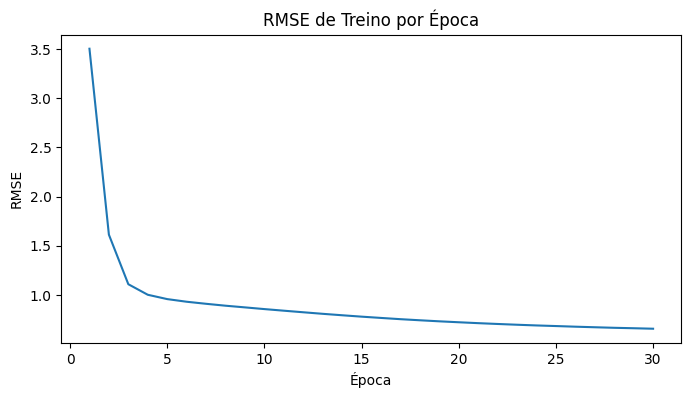

In [8]:
plt.figure(figsize=(8, 4))

plt.plot(
    range(1, N_EPOCHS + 1),
    training_history
)

plt.title("RMSE de Treino por Época")
plt.xlabel("Época")
plt.ylabel("RMSE")

plt.show()

### 4.4 Predição de Scores

Após o treinamento, cada usuário e cada item possuem uma representação no espaço de fatores latentes.

Para um usuário \(u\) e um item \(i\), o score estimado é calculado pelo produto interno entre seus vetores latentes:

\[
\hat{r}_{ui} = p_u^T q_i
\]

Para gerar recomendações, serão considerados apenas os itens pertencentes ao catálogo de treino que ainda não foram observados pelo usuário.

Os candidatos serão ordenados pelo score estimado, permitindo posteriormente selecionar os \(K\) itens com maior valor.

In [9]:
def predict_mf_scores(
    user_id,
    P,
    Q,
    user_to_idx,
    item_to_idx,
    train_catalog,
    seen_items
):
    if user_id not in user_to_idx:
        return pd.Series(dtype=float)

    user_idx = user_to_idx[user_id]

    candidates = utils.get_candidate_items(
        user_id=user_id,
        train_catalog=train_catalog,
        seen_items=seen_items
    )

    scores = {}

    for item_id in candidates:
        if item_id not in item_to_idx:
            continue

        item_idx = item_to_idx[item_id]

        score = (
            P[user_idx]
            @ Q[item_idx]
        )

        scores[item_id] = score

    return pd.Series(
        scores,
        dtype=float
    ).sort_values(ascending=False)

In [10]:
user_id = evaluation_users[0]

mf_scores = predict_mf_scores(
    user_id=user_id,
    P=P,
    Q=Q,
    user_to_idx=user_to_idx,
    item_to_idx=item_to_idx,
    train_catalog=train_catalog,
    seen_items=seen_items
)

mf_scores.head(10)

,0
285,5.796358
169,5.410757
276,5.401450
302,5.287381
652,5.238177
1449,5.236174
511,5.116843
428,5.091134
530,5.068103
228,5.062476


### 4.5 Recomendações Top-K

In [12]:
mf_recommendations = {}

for user_id in evaluation_users:

    scores = predict_mf_scores(
        user_id=user_id,
        P=P,
        Q=Q,
        user_to_idx=user_to_idx,
        item_to_idx=item_to_idx,
        train_catalog=train_catalog,
        seen_items=seen_items
    )

    mf_recommendations[user_id] = (
        scores
        .head(K)
        .index
        .tolist()
    )

In [13]:
recommendation_lengths = pd.Series({
    user_id: len(items)
    for user_id, items in mf_recommendations.items()
})

recommendation_lengths.describe()

,0
count,907.0
mean,10.0
std,0.0
min,10.0
25%,10.0
50%,10.0
75%,10.0
max,10.0


In [14]:
print(
    f"Usuários com menos de {K} recomendações:",
    (recommendation_lengths < K).sum()
)

print(
    "Percentual:",
    f"{(recommendation_lengths < K).mean():.2%}"
)

Usuários com menos de 10 recomendações: 0
Percentual: 0.00%


## 5. Avaliação

### 5.1 Avaliação do modelo

As recomendações produzidas pela Matrix Factorization serão avaliadas utilizando o mesmo protocolo experimental empregado nos modelos anteriores.

Serão utilizadas as métricas Precision@10, Recall@10 e NDCG@10, permitindo comparar diretamente a qualidade do ranking produzido pelo modelo com os baselines e demais abordagens implementadas.

In [15]:
mf_results, mf_summary = (
    utils.evaluate_recommendations(
        recommendations=mf_recommendations,
        ground_truth=ground_truth,
        k=K
    )
)

mf_summary

{'Precision@10': np.float64(0.04707828004410144),
 'Recall@10': np.float64(0.04447660358961688),
 'NDCG@10': np.float64(0.05745053251897024),
 'n_users': 907}

In [16]:
comparison = utils.add_model_result(
    results_df=model_results,
    model_name="Matrix Factorization",
    summary=mf_summary,
    k=K
)

comparison

,model,Precision@10,Recall@10,NDCG@10,n_users
0,Random,0.007387,0.006949,0.008209,907
1,Popularity,0.077508,0.078646,0.098883,907
2,Content-Based,0.018964,0.018318,0.025018,907
3,User-Based CF,0.013671,0.011940,0.015679,907
4,Item-Based CF,0.020510,0.015440,0.021430,907
5,Matrix Factorization,0.047078,0.044477,0.057451,907


### 5.2 Comparação com os modelos anteriores

A Matrix Factorization apresentou o melhor desempenho entre os modelos personalizados avaliados até esta etapa.

| Modelo | Precision@10 | Recall@10 | NDCG@10 |
|---|---:|---:|---:|
| Random | 0.00739 | 0.00695 | 0.00821 |
| Popularity | **0.07751** | **0.07865** | **0.09888** |
| Content-Based | 0.01896 | 0.01832 | 0.02502 |
| User-Based CF | 0.01367 | 0.01194 | 0.01568 |
| Item-Based CF | 0.02051 | 0.01544 | 0.02143 |
| Matrix Factorization | 0.04708 | 0.04448 | 0.05745 |

A Matrix Factorization superou Content-Based, User-Based CF e Item-Based CF nas três métricas de ranking.

O resultado indica que a representação de usuários e itens por fatores latentes conseguiu capturar padrões de preferência que não foram representados de forma tão eficiente pelos métodos baseados em conteúdo ou vizinhança.

O Popularity Baseline, entretanto, permaneceu como o modelo de melhor desempenho global. Esse resultado evidencia a forte influência da popularidade dos itens no protocolo experimental utilizado e reforça a importância de comparar modelos personalizados com baselines simples.

A Matrix Factorization utilizada nesta etapa corresponde a uma implementação básica, na qual a predição é realizada exclusivamente pelo produto interno entre os fatores latentes do usuário e do item:

\[
\hat{r}_{ui}=p_u^Tq_i
\]

Extensões como biases globais, de usuário e de item, além de seleção sistemática de hiperparâmetros, poderão ser avaliadas posteriormente.

## 6. Conclusões

Neste notebook foi implementado um modelo de **Matrix Factorization from scratch**, utilizando NumPy e Stochastic Gradient Descent (SGD).

Diferentemente dos métodos de Collaborative Filtering baseados em vizinhança, a Matrix Factorization representa usuários e itens por meio de fatores latentes aprendidos diretamente a partir dos padrões de ratings.

A implementação utilizou a formulação:

\[
\hat{r}_{ui} = p_u^T q_i
\]

e apresentou os seguintes resultados:

| Modelo | Precision@10 | Recall@10 | NDCG@10 |
|---|---:|---:|---:|
| Random | 0.00739 | 0.00695 | 0.00821 |
| Popularity | **0.07751** | **0.07865** | **0.09888** |
| Content-Based | 0.01896 | 0.01832 | 0.02502 |
| User-Based CF | 0.01367 | 0.01194 | 0.01568 |
| Item-Based CF | 0.02051 | 0.01544 | 0.02143 |
| Matrix Factorization | 0.04708 | 0.04448 | 0.05745 |

A Matrix Factorization apresentou o **melhor desempenho entre os modelos personalizados**, superando Content-Based, User-Based CF e Item-Based CF nas três métricas avaliadas.

O Popularity Baseline permaneceu como o modelo de melhor desempenho global, evidenciando a força do sinal de popularidade no MovieLens 100K e no protocolo experimental utilizado.

Apesar de simples, a implementação demonstrou a capacidade dos fatores latentes de representar padrões de preferência que não são explicitamente fornecidos ao modelo.

A versão implementada não inclui extensões como biases de usuário e item, early stopping ou otimização sistemática de hiperparâmetros. Essas técnicas representam possíveis evoluções do modelo, mas não foram exploradas neste experimento.

Com esta etapa, o projeto cobre uma progressão desde baselines simples até diferentes estratégias de personalização:

**Random → Popularity → Content-Based → User-Based CF → Item-Based CF → Matrix Factorization.**